# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




O teste é unilateral à direita, pois a hipótese alternativa afirma que a média das notas da Estratégia B é maior do que a média da Estratégia A (μB > μA).

- Assim, estamos interessados apenas em verificar se a média da Estratégia B é maior, e não apenas diferente, o que caracteriza um teste unilateral à direita.

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [3]:
# Cálculo das médias
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)

# Cálculo das variâncias
variancia_A = np.var(amostra_estrategia_A, ddof=1)
variancia_B = np.var(amostra_estrategia_B, ddof=1)

print("Média Estratégia A:", media_A)
print("Média Estratégia B:", media_B)

print("Variância Estratégia A:", variancia_A)
print("Variância Estratégia B:", variancia_B)

Média Estratégia A: 71.40559272313098
Média Estratégia B: 74.74868110507046
Variância Estratégia A: 129.2654943565623
Variância Estratégia B: 110.4700206552835


## Insights
- A média da Estratégia B foi maior que a da Estratégia A, indicando que os alunos submetidos à Estratégia B apresentaram desempenho médio superior.

- Ao comparar as variâncias, observa-se que a Estratégia A apresentou maior variabilidade nas notas do que a Estratégia B, indicando que os resultados da Estratégia B foram um pouco mais consistentes.

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [4]:
# Tamanho das amostras
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

# Erro padrão
erro_padrao = np.sqrt(
    (variancia_A / n_A) +
    (variancia_B / n_B)
)

# Estatística Z
z = (media_B - media_A) / erro_padrao

# p-valor unilateral à direita
p_valor = 1 - stats.norm.cdf(z)

print("Estatística Z:", z)
print("p-valor:", p_valor)

# Nível de significância
alpha = 0.05

if p_valor < alpha:
    print("Rejeitamos a hipótese nula (H0)")
else:
    print("Não rejeitamos a hipótese nula (H0)")

Estatística Z: 1.5267455833477102
p-valor: 0.06341214386181693
Não rejeitamos a hipótese nula (H0)


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

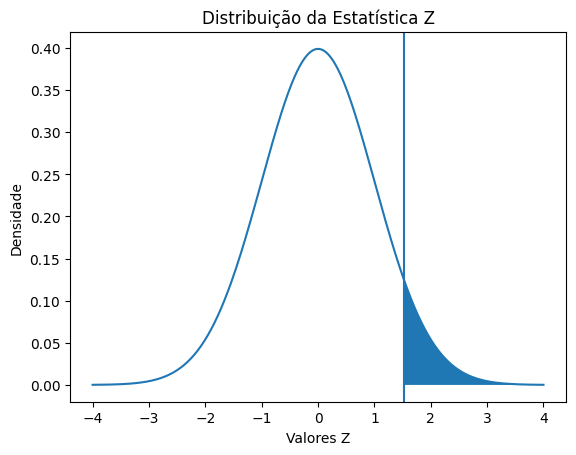

In [5]:
# Valores da curva normal
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)

plt.figure()
plt.plot(x, y)

# Linha da estatística Z
plt.axvline(z)

# Região do p-valor
x_fill = np.linspace(z, 4, 200)
plt.fill_between(
    x_fill,
    stats.norm.pdf(x_fill)
)

plt.title("Distribuição da Estatística Z")
plt.xlabel("Valores Z")
plt.ylabel("Densidade")

plt.show()

## Explicação do Gráfico
- O gráfico apresenta a distribuição normal padrão, onde a linha vertical representa o valor da estatística Z calculada.

- A área sombreada à direita da linha representa o p-valor, ou seja, a probabilidade de obter um valor igual ou maior que o observado considerando que a hipótese nula seja verdadeira.

- Como a estatística Z não se encontra em uma região crítica da curva, a área sombreada não é suficientemente pequena para rejeitar a hipótese nula, indicando que não há evidências estatísticas suficientes para afirmar que a Estratégia B é superior à Estratégia A.